In [1]:
# 1. Instalación de Librerías
# Se instalan las librerías de Python necesarias para el proyecto.
%pip install matplotlib
%pip install seaborn
%pip install mysql-connector-python
%pip install sqlalchemy
%pip install streamlit

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# 2. Importación de Librerías
# Se importan las librerías que se utilizarán a lo largo del notebook.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import mysql.connector

from sqlalchemy import create_engine

In [3]:
# 3. Carga de Datos
# Se cargan los conjuntos de datos desde archivos CSV.
tracks = pd.read_csv('../data/tracks.csv')

artists = pd.read_csv('../data/artists.csv')

In [4]:
# 4. Verificación de Dimensiones
# Se imprime la forma (filas, columnas) de los DataFrames.
print(tracks.shape)
print(artists.shape)

(586672, 20)
(1162095, 5)


In [5]:
# 5. Vista Previa de Pistas (Tracks)
# Se muestra una vista previa de las primeras filas del DataFrame de pistas.
tracks.head()

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


In [6]:
# 6. Vista Previa de Artistas
# Se muestra una vista previa de las primeras filas del DataFrame de artistas.
artists.head()

,id,followers,genres,name,popularity
0,0DheY5irMjBUeLybbCUEZ2,0.0,[],Armid & Amir Zare Pashai feat. Sara Rouzbehani,0
1,0DlhY15l3wsrnlfGio2bjU,5.0,[],ปูนา ภาวิณี,0
2,0DmRESX2JknGPQyO15yxg7,0.0,[],Sadaa,0
3,0DmhnbHjm1qw6NCYPeZNgJ,0.0,[],Tra'gruda,0
4,0Dn11fWM7vHQ3rinvWEl4E,2.0,[],Ioannis Panoutsopoulos,0


In [7]:
# 7. Muestreo de Datos
# Se toma una muestra aleatoria de 50,000 registros para un análisis más manejable.
tracks = tracks.sample(
    50000,
    random_state=42
)

In [8]:
# 8. Verificación del Muestreo
# Se comprueba la nueva dimensión del DataFrame de pistas tras el muestreo.
print(tracks.shape)

(50000, 20)


In [9]:
# 9. Eliminación de Duplicados
# Se eliminan filas duplicadas de ambos DataFrames para asegurar la calidad de los datos.
tracks = tracks.drop_duplicates()

artists = artists.drop_duplicates()

In [10]:
# 10. Conversión de Fechas
# Se convierte la columna 'release_date' a formato datetime.
tracks['release_date'] = pd.to_datetime(
    tracks['release_date'],
    format='mixed',
    errors='coerce'
)

In [11]:
# 11. Extracción del Año de Lanzamiento
# Se crea una nueva columna 'release_year' extrayendo el año de 'release_date'.
tracks['release_year'] = (
    tracks['release_date']
    .dt.year
)

In [12]:
# 12. Verificación de la Columna de Año
# Se muestran las columnas de fecha y año para verificar la extracción.
tracks[['release_date', 'release_year']].head()

,release_date,release_year
241517,1985-01-01,1985
444213,2017-08-25,2017
106480,1992-01-01,1992
141137,1969-01-01,1969
586550,2015-12-25,2015


In [13]:
# 13. Conteo de Valores Nulos
# Se cuentan los valores nulos en cada columna para identificar datos faltantes.
tracks.isnull().sum()

id                  0
name                4
popularity          0
duration_ms         0
explicit            0
artists             0
id_artists          0
release_date        0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
release_year        0
dtype: int64

In [14]:
# 14. Eliminación de Filas con Años Nulos
# Se eliminan las filas donde el año de lanzamiento es nulo.
tracks = tracks.dropna(
    subset=['release_year']
)

In [15]:
# 15. Creación de Subconjuntos para la Base de Datos
# Se crean copias de los primeros 5000 registros para un conjunto de prueba.
tracks_db = tracks.head(5000).copy()

artists_db = artists.head(5000).copy()

In [16]:
# 16. Vista Previa del DataFrame de Pistas
# Se muestra una vista previa del DataFrame 'tracks' después de las transformaciones.
tracks.head()

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,release_year
241517,0rTUAMd7huYjda84aceuzl,Дети проходных дворов,21,105015,0,['Kino'],['2jkl2xJVm71azWAgZKyf42'],1985-01-01,0.890,0.6680,...,-10.044,0,0.0533,0.570,0.000002,0.0591,0.942,137.934,4,1985
444213,4bMy8NjgkVHize43OSrChu,95,37,234800,0,['Picture This'],['7jLSEPYCYQ5ssWU3BICqrW'],2017-08-25,0.663,0.5510,...,-6.445,1,0.0280,0.697,0.000000,0.1800,0.339,128.992,4,2017
106480,4X1xn2bjxlaLbx6o3jSEXj,As almal ver is,10,147733,0,['Koos Du Plessis'],['4utxbudXUuseiCfVJ0B2xM'],1992-01-01,0.376,0.0979,...,-18.280,1,0.0350,0.485,0.000577,0.1150,0.236,90.290,3,1992
141137,3ZwzDf7V1xlAS9WWuviqIm,"Il tuo mondo (Nono, dobri moj nono)",29,194373,0,['Claudio Villa'],['2r4iOKmxTQU9s361Yt3gq1'],1969-01-01,0.565,0.3270,...,-13.843,1,0.0295,0.781,0.000011,0.1310,0.556,103.256,3,1969
586550,712Hktc9DnU5u9uOSn1q1Y,Bazaar - Official Sunburn Goa 2015 Anthem,55,172500,0,"['KSHMR', 'Marnik']","['2wX6xSig4Rig5kZU6ePlWe', '6S3KljEiIOWoLMUyZr...",2015-12-25,0.582,0.9790,...,-2.492,0,0.0714,0.125,0.001520,0.3390,0.196,128.010,4,2015


In [17]:
# 17. Filtrado y Limpieza para la Base de Datos
# Se asegura la integridad referencial filtrando pistas por artistas válidos.
# Seleccionar 5000 artistas
artists_db = artists.head(5000).copy()

# Obtener ids válidos
artist_ids = set(artists_db['id'])

# Limpiar ids de tracks
tracks['artist_id_clean'] = (
    tracks['id_artists']
    .astype(str)
    .apply(lambda x: x.split(",")[0]
           .replace("[","")
           .replace("]","")
           .replace("'","")
           .strip())
)

# Filtrar tracks
tracks_db = tracks[
    tracks['artist_id_clean'].isin(artist_ids)
].copy()

In [18]:
# 18. Verificación de Dimensiones Post-Limpieza
# Se comprueban las dimensiones de los DataFrames para la BD.
print(tracks_db.shape)
print(artists_db.shape)

(486, 22)
(5000, 5)


In [42]:
# 19. Selección de Columnas de Artistas
# Se crea un DataFrame de artistas limpio con solo 'id' y 'name'.
artists_clean = artists_db[[
    'id',
    'name'
]].copy()

In [43]:
# 20. Renombrado de Columnas de Artistas
# Se renombran las columnas para mayor claridad.
artists_clean.columns = [
    'artist_id',
    'artist_name'
]

In [44]:
# 21. Limpieza Final del DataFrame de Artistas
# Se eliminan duplicados y nulos del DataFrame de artistas.
artists_clean = (
    artists_clean
    .drop_duplicates()
    .dropna()
)

In [45]:
# 22. Vista Previa de Artistas Limpios
# Se verifica el resultado final de la limpieza de artistas.
artists_clean.head()

,artist_id,artist_name
0,0DheY5irMjBUeLybbCUEZ2,Armid & Amir Zare Pashai feat. Sara Rouzbehani
1,0DlhY15l3wsrnlfGio2bjU,ปูนา ภาวิณี
2,0DmRESX2JknGPQyO15yxg7,Sadaa
3,0DmhnbHjm1qw6NCYPeZNgJ,Tra'gruda
4,0Dn11fWM7vHQ3rinvWEl4E,Ioannis Panoutsopoulos


In [46]:
# 23. Extracción del ID de Artista en Pistas
# Se extrae y limpia el ID del artista principal para cada pista.
tracks_db['artist_id'] = (
    tracks_db['id_artists']
    .astype(str)
    .str.split(',')
    .str[0]
    .str.replace(r"[\"\'\[\] ]", "", regex=True)
)

In [47]:
# 24. Selección de Columnas de Pistas
# Se seleccionan las columnas relevantes para el DataFrame de pistas limpio.
tracks_clean = tracks_db[[
    'id',
    'name',
    'artist_id',
    'release_year',
    'popularity',
    'danceability',
    'energy',
    'valence',
    'acousticness',
    'duration_ms',
    'tempo'
]].copy()

In [48]:
# 25. Renombrado de Columnas de Pistas
# Se renombran las columnas del DataFrame de pistas para mayor consistencia.
tracks_clean.columns = [
    'track_id',
    'track_name',
    'artist_id',
    'release_year',
    'popularity',
    'danceability',
    'energy',
    'valence',
    'acousticness',
    'duration_ms',
    'tempo'
]

In [49]:
# 26. Limpieza Final del DataFrame de Pistas
# Se eliminan duplicados y nulos del DataFrame de pistas.
tracks_clean = (
    tracks_clean
    .drop_duplicates()
    .dropna()
)

In [50]:
# 27. Vista Previa de Pistas Limpias
# Se verifica el resultado final de la limpieza de pistas.
tracks_clean.head()

,track_id,track_name,artist_id,release_year,popularity,danceability,energy,valence,acousticness,duration_ms,tempo
377252,5hAWpZAImdbjkU5dgr0KoZ,Verlangen,2rba1PuLCc0Q4EzNW4RU68,1990,11,0.646,0.495,0.963,0.2990,197133,145.431
353930,6XJUe1AqJeSb2mdwOtFbMv,ozi Diven Sviat,43kL15nJXxOZxlCqum23RG,1970,6,0.468,0.527,0.430,0.5620,182044,89.996
356842,39KoejkN7VCwc8OOAYs1Ei,Sbogom,3F7y6OKpRQVTYknMF3weXr,2009,21,0.260,0.463,0.142,0.0685,240213,75.168
354704,4PmByxVhnWfcOApypfe6CF,Това е изкуство,4Y2cX4q4jApCCB5ML0VBMD,1982,2,0.524,0.667,0.860,0.5710,290867,116.796
474760,2ztRpiApkVtZrYHZKDgaLH,Atrapado en Tus Redes,1g31gW7m6FH9LljAfobGh8,2007,37,0.645,0.505,0.766,0.5190,203651,152.623


In [51]:
# 28. Conexión a la Base de Datos
# Se define la cadena de conexión y se crea el motor de SQLAlchemy.
# Nota: Las credenciales expuestas son una mala práctica de seguridad.
from sqlalchemy import create_engine

DATABASE_URL = (
    "mysql+pymysql://"
    "DocBxbiNM1cbnzj.root:slWnqaS2ilBHBfHl"
    "@gateway01.us-west-2.prod.aws.tidbcloud.com:4000/"
    "spotify_db"
    "?ssl_verify_cert=false&ssl_verify_identity=false"
)

engine = create_engine(
    DATABASE_URL
)

In [52]:
# 29. Re-creación del Motor de Conexión (Redundante)
# Esta celda vuelve a crear el motor, lo cual es innecesario.
engine = create_engine(
    DATABASE_URL
)

In [53]:
# 30. Mensaje de Confirmación
print('Conexión creada correctamente')

Conexión creada correctamente


In [54]:
# 31. Prueba de Conexión
# Se prueba la conexión para asegurar que la configuración es correcta.
with engine.connect() as conn:
    print("Conexión OK")

Conexión OK


In [55]:
# 32. Inserción de Nuevos Artistas
# Se insertan en la BD solo los artistas que no existen previamente.
# Leer los IDs de los artistas que ya existen en la base de datos
with engine.connect() as conn:
    existing_artists = pd.read_sql("SELECT artist_id FROM artists", conn)
    existing_artist_ids = existing_artists['artist_id'].tolist()

# Filtrar el DataFrame para obtener solo los nuevos artistas
new_artists = artists_clean[~artists_clean['artist_id'].isin(existing_artist_ids)]

# Insertar solo los nuevos artistas
if not new_artists.empty:
    new_artists.to_sql(
        name='artists',
        con=engine,
        if_exists='append',
        index=False,
        chunksize=100,
        method='multi'
    )

In [56]:
# 33. Confirmación de Inserción de Artistas
print('Artists insertados correctamente')

Artists insertados correctamente


In [63]:
# 34. Inserción de Pistas
# Se verifica qué pistas ya existen para no insertarlas de nuevo.

# Leer los IDs de las pistas que ya existen en la base de datos
with engine.connect() as conn:
    try:
        existing_tracks = pd.read_sql("SELECT track_id FROM tracks", conn)
        existing_track_ids = existing_tracks['track_id'].tolist()
        
        # Filtrar el DataFrame para obtener solo las nuevas pistas
        new_tracks = tracks_clean[~tracks_clean['track_id'].isin(existing_track_ids)]
    except Exception as e:
        # Si la tabla no existe, insertamos todo el dataframe
        print("La tabla 'tracks' podría no existir, se intentará insertar todos los datos.")
        new_tracks = tracks_clean

# Insertar solo las nuevas pistas
if not new_tracks.empty:
    new_tracks.to_sql(
        name='tracks',
        con=engine,
        if_exists='append',
        index=False,
        chunksize=100,
        method='multi'
    )
    print(f"{len(new_tracks)} pistas nuevas insertadas correctamente.")
else:
    print("No había pistas nuevas para insertar.")

No había pistas nuevas para insertar.


In [64]:
# 35. Confirmación de Inserción de Pistas
print('Tracks insertados correctamente')

Tracks insertados correctamente


In [65]:
# 36. Definición de Consulta SQL
# Se define una consulta SQL para seleccionar características de las pistas.
query = """
SELECT
    t.track_name,
    t.release_year,
    t.popularity,
    t.energy,
    t.danceability,
    t.valence,
    t.tempo
FROM tracks t
"""

In [66]:
# 37. Ejecución de Consulta y Carga en DataFrame
# Se ejecuta la consulta y se cargan los resultados en un DataFrame.
df_sql = pd.read_sql(
    query,
    engine
)

In [67]:
# 38. Vista Previa de Datos desde SQL
# Se muestra una vista previa de los datos recuperados de la BD.
df_sql.head()

,track_name,release_year,popularity,energy,danceability,valence,tempo
0,Popozuda Rock 'N' Roll,2000,38,0.849,0.836,0.728,130.246
1,Tu Mamá Te Mató,2015,43,0.490,0.568,0.255,130.021
2,Como Tu Enemigo,2009,37,0.882,0.656,0.909,90.982
3,Kruska,2010,37,0.703,0.629,0.845,171.861
4,Is er een ander (tussen jou en mij)?,1973,23,0.470,0.327,0.549,107.544


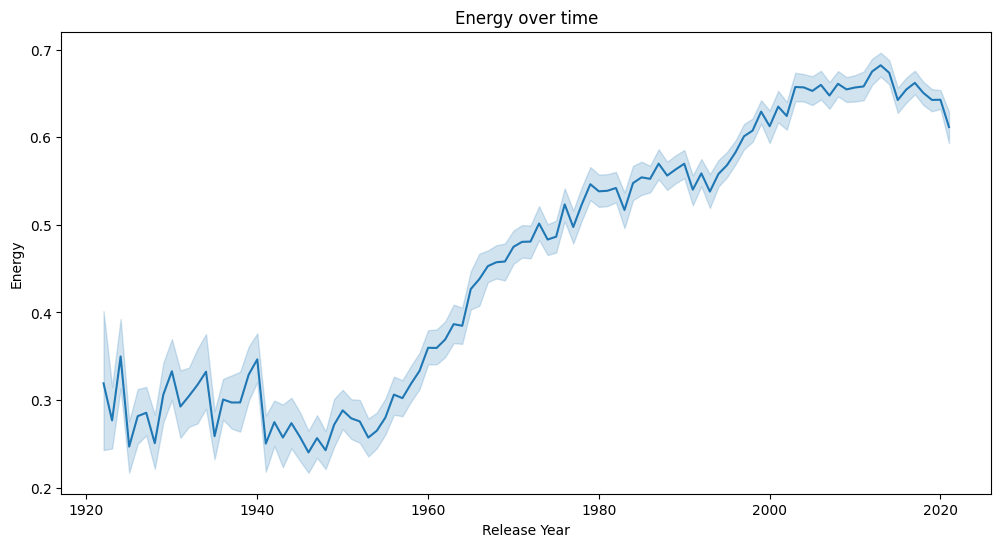

In [68]:
# 39. Visualización: Energía a lo Largo del Tiempo
# Se visualiza el cambio de la 'energía' de las canciones a lo largo de los años.
plt.figure(figsize=(12,6))

sns.lineplot(
    data=tracks,
    x='release_year',
    y='energy'
)

plt.title('Energy over time')

plt.xlabel('Release Year')

plt.ylabel('Energy')

plt.show()

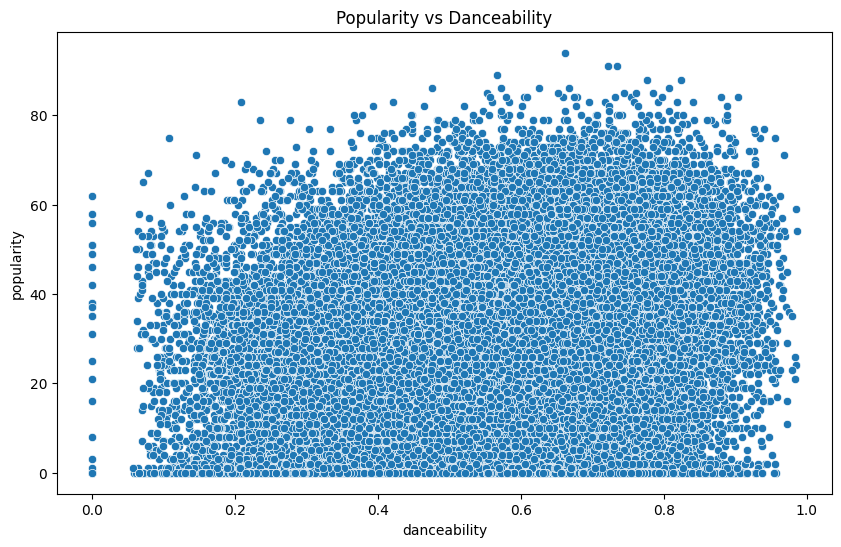

In [69]:
# 40. Visualización: Popularidad vs. Bailabilidad
# Se explora la relación entre 'danceability' y 'popularity'.
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=tracks,
    x='danceability',
    y='popularity'
)

plt.title('Popularity vs Danceability')

plt.show()

In [70]:
# 41. Cálculo de Matriz de Correlación
# Se calcula la correlación entre varias características numéricas.
corr = tracks[[
    'popularity',
    'danceability',
    'energy',
    'valence',
    'tempo'
]].corr()

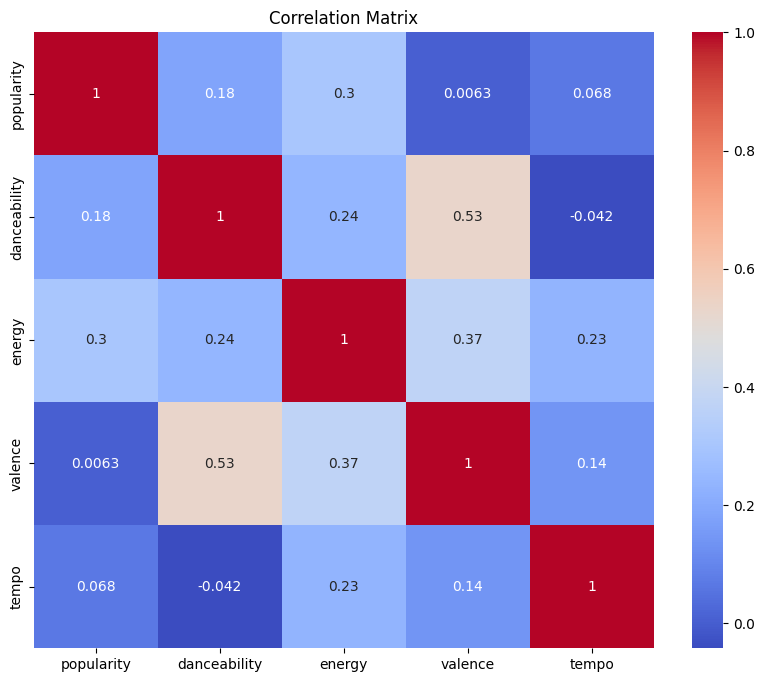

In [71]:
# 42. Visualización: Mapa de Calor de Correlaciones
# Se visualiza la matriz de correlación como un mapa de calor.
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

In [72]:
# 43. Exportación del Conjunto de Datos Analítico
# Se guarda el DataFrame procesado en un archivo CSV para la app de Streamlit.
tracks.to_csv(
    '../exports/analytical_dataset.csv',
    index=False
)

In [73]:
# 44. Confirmación de Exportación
print('Dataset exportado correctamente')

Dataset exportado correctamente
